# Partie III – Génération de Données Synthétiques (DC2)
Groupe 6: Dorsa AGHAJANI, Rym MOUSLI, Fatima zahra SAAD

Approche : Échantillonnage dans l'espace de l'ACP, inspirée de Guillaudeux et al. (2023).

Principe :
1. Imputation des valeurs manquantes par médiane/mode
2. Standardisation des variables
3. ACP pour réduire la dimension (95% de variance expliquée)
4. Modélisation de la distribution des scores ACP par une loi normale multivariée
5. Échantillonnage dans cet espace latent
6. Projection inverse vers l'espace original
7. Post-traitement (types, bornes) et réinjection du schéma de données manquantes
8. Évaluation : distance de Wasserstein, corrélations, plus proche voisin

Référence: Guillaudeux M. et al. (2023). Patient-centric synthetic data generation, no reason to risk re-identification in clinical data analysis. npj Digital Medicine, 6, 37.

In [46]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.neighbors import NearestNeighbors
from scipy.stats import wasserstein_distance, pearsonr
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.metrics import pairwise_distances
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
import warnings
import seaborn as sns
warnings.filterwarnings('ignore')

##Chargement des données

In [18]:
df = pd.read_csv("/content/drive/MyDrive/M1/S2/data 2/trainDataDC2.csv")
df

,patid,index_age,previous_asthma_drugs,total_pre_index_cannisters_365,post_index_exacerbations365,pneumonia,sinusitis,acute_bronchitis,acute_laryngitis,upper_respiratory_infection,...,rhinitis,adherence,total_pre_index_charge,pre_asthma_days,pre_asthma_charge,pre_asthma_pharma_charge,drug_s,female,log_charges,log_asthma_charge
0,1073754155,14.0,1.0,1.0,0,0.0,0.0,1.0,0.0,1.0,...,0.0,NaN,1224.767473,1.0,314.0,218.13,0.0,NaN,7.110506,5.385091
1,1073799394,NaN,1.0,2.0,2,0.0,1.0,1.0,0.0,0.0,...,1.0,NaN,20290.534269,0.0,NaN,44.98,0.0,0.0,9.917910,3.806218
2,1073854918,62.0,1.0,NaN,0,0.0,0.0,NaN,0.0,0.0,...,0.0,0.738420,2964.254175,NaN,480.0,99.26,0.0,0.0,7.994381,4.597743
3,1073898249,NaN,1.0,2.0,0,0.0,0.0,1.0,0.0,1.0,...,0.0,0.084469,3223.708820,0.0,0.0,59.58,0.0,1.0,8.078288,NaN
4,1073913003,40.0,1.0,1.0,0,0.0,1.0,0.0,1.0,1.0,...,1.0,0.506812,1287.254368,2.0,689.0,NaN,0.0,0.0,7.160267,3.394173
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
14570,1608866296,28.0,1.0,1.0,0,0.0,1.0,0.0,0.0,1.0,...,1.0,0.784741,4031.590780,2.0,2398.0,125.04,1.0,0.0,8.301916,4.828634
14571,1609025178,63.0,NaN,0.0,0,0.0,1.0,0.0,NaN,NaN,...,0.0,0.836512,NaN,0.0,0.0,2143.50,1.0,0.0,8.881267,7.670195
14572,1609186140,34.0,1.0,1.0,0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.084469,33667.611169,0.0,0.0,1.63,1.0,1.0,10.424292,0.488580
14573,1609921811,NaN,1.0,2.0,1,0.0,0.0,0.0,0.0,0.0,...,1.0,0.482289,961.265928,2.0,NaN,114.78,1.0,NaN,6.868251,4.743017


In [20]:
df.shape

(14575, 21)

##Identification des types de variables

In [19]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 14575 entries, 0 to 14574
Data columns (total 21 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   patid                           14575 non-null  int64  
 1   index_age                       13085 non-null  float64
 2   previous_asthma_drugs           13144 non-null  float64
 3   total_pre_index_cannisters_365  13131 non-null  float64
 4   post_index_exacerbations365     14575 non-null  int64  
 5   pneumonia                       13072 non-null  float64
 6   sinusitis                       13084 non-null  float64
 7   acute_bronchitis                13127 non-null  float64
 8   acute_laryngitis                13166 non-null  float64
 9   upper_respiratory_infection     13114 non-null  float64
 10  gerd                            13108 non-null  float64
 11  rhinitis                        13109 non-null  float64
 12  adherence                       

In [21]:
id_col = 'patid'

# Variables continues
continuous_cols = [
    'index_age', 'total_pre_index_cannisters_365', 'adherence',
    'total_pre_index_charge', 'pre_asthma_days', 'pre_asthma_charge',
    'pre_asthma_pharma_charge', 'log_charges', 'log_asthma_charge'
]

# Variables binaires (0/1)
binary_cols = [
    'previous_asthma_drugs', 'pneumonia', 'sinusitis', 'acute_bronchitis',
    'acute_laryngitis', 'upper_respiratory_infection', 'gerd', 'rhinitis',
    'drug_s', 'female'
]

# Variable de comptage
count_col = 'post_index_exacerbations365'

feature_cols = continuous_cols + binary_cols + [count_col]

print("Variables continues :", len(continuous_cols))
print("Variables binaires  :", len(binary_cols))
print("Variables de comptage :", 1)
print("\nTaux de valeurs manquantes (%):")
miss = df[feature_cols].isnull().mean() * 100
print(miss[miss > 0].round(1).to_string())

Variables continues : 9
Variables binaires  : 10
Variables de comptage : 1

Taux de valeurs manquantes (%):
index_age                         10.2
total_pre_index_cannisters_365     9.9
adherence                         12.8
total_pre_index_charge            10.1
pre_asthma_days                   10.0
pre_asthma_charge                 10.1
pre_asthma_pharma_charge           9.7
log_charges                        9.8
log_asthma_charge                  9.5
previous_asthma_drugs              9.8
pneumonia                         10.3
sinusitis                         10.2
acute_bronchitis                   9.9
acute_laryngitis                   9.7
upper_respiratory_infection       10.0
gerd                              10.1
rhinitis                          10.1
drug_s                             9.5
female                             9.7


In [22]:
missing_values = df.isna().sum()

missing_values[missing_values > 0]

,0
index_age,1490
previous_asthma_drugs,1431
total_pre_index_cannisters_365,1444
pneumonia,1503
sinusitis,1491
acute_bronchitis,1448
acute_laryngitis,1409
upper_respiratory_infection,1461
gerd,1467
rhinitis,1466


##Imputation des valeurs manquantes

Les valeurs manquantes sont imputées par la médiane pour les variables continues
et par le mode pour les variables binaires, avant d'entrer dans l'ACP.
Le schéma de données manquantes observé sera réinjecté dans les données synthétiques.

In [23]:
X = df[feature_cols].copy()

# Sauvegarder les taux de missing pour réinjection ultérieure
missing_rates = {c: df[c].isnull().mean() for c in feature_cols}

# Imputation
medians = X[continuous_cols].median()
X[continuous_cols] = X[continuous_cols].fillna(medians)

for c in binary_cols:
    mode_val = X[c].mode()[0]
    X[c] = X[c].fillna(mode_val)

# Vérification
print("Valeurs manquantes après imputation:", X.isnull().sum().sum())
print(f"Matrice de features : {X.shape}")

Valeurs manquantes après imputation: 0
Matrice de features : (14575, 20)


In [24]:
numeric_features = df.select_dtypes(
    include=["int64", "float64"]
).columns

categorical_features = df.select_dtypes(
    include=["object", "category"]
).columns

print("Variables numériques :", len(numeric_features))
print("Variables catégorielles :", len(categorical_features))

Variables numériques : 21
Variables catégorielles : 0


In [25]:
numeric_pipeline = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler())
    ])

In [26]:
if len(categorical_features) > 0:

    categorical_pipeline = Pipeline(
        steps=[
            ("imputer", SimpleImputer(strategy="most_frequent")),
            ("encoder", OneHotEncoder(handle_unknown="ignore"))
        ]
    )

    preprocessor = ColumnTransformer(
        transformers=[
            ("num", numeric_pipeline, numeric_features),
            ("cat", categorical_pipeline, categorical_features)
        ]
    )

else:

    preprocessor = ColumnTransformer(
        transformers=[
            ("num", numeric_pipeline, numeric_features)
        ])

In [27]:
X_processed = preprocessor.fit_transform(df)
X_processed.shape

(14575, 21)

##Standardisation et ACP
L'ACP est appliquée sur les données standardisées.  
On retient le nombre de composantes permettant d'expliquer 95% de la variance totale.

Nombre de composantes retenues : 17
Variance expliquée totale      : 0.956


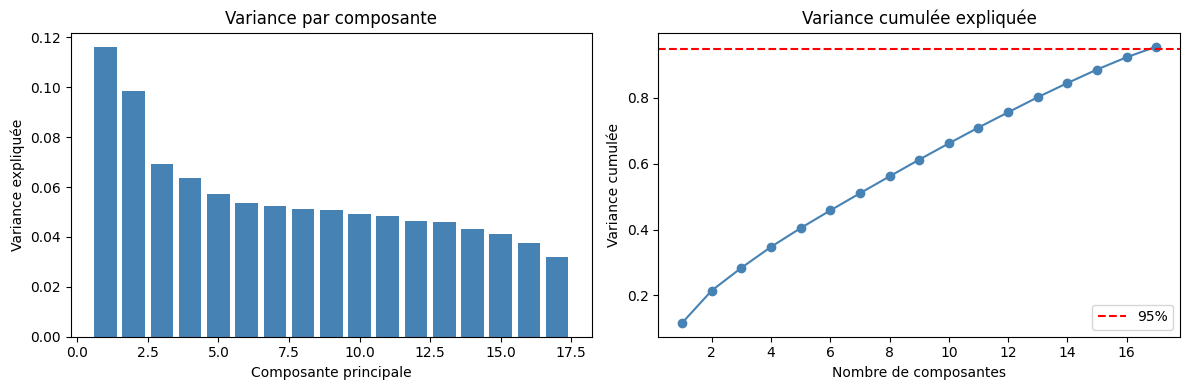

Figure sauvegardée : pca_variance.png


In [28]:
# Standardisation
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# ACP
pca = PCA(n_components=0.95, random_state=42)
Z = pca.fit_transform(X_scaled)

print(f"Nombre de composantes retenues : {pca.n_components_}")
print(f"Variance expliquée totale      : {pca.explained_variance_ratio_.sum():.3f}")

# Visualisation
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].bar(range(1, pca.n_components_+1), pca.explained_variance_ratio_, color='steelblue')
axes[0].set_xlabel("Composante principale")
axes[0].set_ylabel("Variance expliquée")
axes[0].set_title("Variance par composante")

axes[1].plot(range(1, pca.n_components_+1),
             np.cumsum(pca.explained_variance_ratio_), 'o-', color='steelblue')
axes[1].axhline(0.95, color='red', linestyle='--', label='95%')
axes[1].set_xlabel("Nombre de composantes")
axes[1].set_ylabel("Variance cumulée")
axes[1].set_title("Variance cumulée expliquée")
axes[1].legend()

plt.tight_layout()
plt.savefig("pca_variance.png", dpi=100, bbox_inches='tight')
plt.show()
print("Figure sauvegardée : pca_variance.png")

In [45]:
pca = PCA(
    n_components=pca.n_components_
)

X_pca = pca.fit_transform(
    X_processed
)
print(X_pca.shape)

(14575, 17)


##Génération synthétique – Échantillonnage dans l'espace latent

Conformément à l'approche de Guillaudeux et al. (2023), on modélise la distribution des
scores ACP par une **loi normale multivariée** ajustée sur les données réelles.  
On tire ensuite $n$ nouveaux individus dans cet espace latent.

Espace latent synthétique généré : (14575, 17)


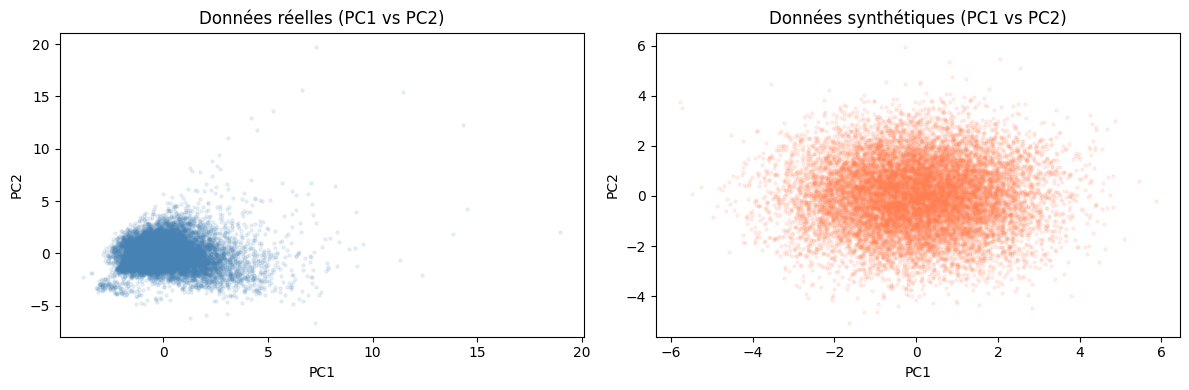

In [31]:
n = len(df)  # même taille que le jeu d'entrainement

# Ajustement de la loi normale multivariée sur les scores ACP
mu_Z = Z.mean(axis=0)
cov_Z = np.cov(Z.T)

# Échantillonnage
Z_syn = np.random.multivariate_normal(mu_Z, cov_Z, size=n)
print(f"Espace latent synthétique généré : {Z_syn.shape}")

# Visualisation des deux premières composantes
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].scatter(Z[:, 0], Z[:, 1], alpha=0.1, s=5, color='steelblue', label='Réel')
axes[0].set_title("Données réelles (PC1 vs PC2)")
axes[0].set_xlabel("PC1"); axes[0].set_ylabel("PC2")

axes[1].scatter(Z_syn[:, 0], Z_syn[:, 1], alpha=0.1, s=5, color='coral', label='Synthétique')
axes[1].set_title("Données synthétiques (PC1 vs PC2)")
axes[1].set_xlabel("PC1"); axes[1].set_ylabel("PC2")

plt.tight_layout()
plt.savefig("pca_sampling.png", dpi=100, bbox_inches='tight')
plt.show()

In [32]:
# Statistiques dans l'espace ACP
mean_pca = np.mean(X_pca, axis=0)
std_pca = np.std(X_pca, axis=0)

print("Moyenne des composantes :")
print(mean_pca)

print("Écart-type des composantes :")
print(std_pca)

Moyenne des composantes :
[ 2.13284698e-18 -1.62248716e-16  3.47349365e-17 -5.16339401e-17
  7.86030284e-17 -5.89031397e-16  1.15575931e-15  5.52245499e-17
  3.16628751e-16 -2.03759251e-16  5.66347045e-17  1.45642979e-17
  4.10279777e-16 -4.34080064e-16  3.89823489e-16  1.62957126e-16
 -8.48473188e-18]
Écart-type des composantes :
[1.48511789 1.36813516 1.14674383 1.09986125 1.04176917 1.01192631
 1.00286509 0.99649179 0.98704703 0.98268157 0.96787988 0.95751756
 0.93361249 0.93248919 0.90485062 0.8828291  0.84289877]


In [33]:
mean_pca = np.mean(
    X_pca,
    axis=0)

std_pca = np.std(
    X_pca,
    axis=0
)

In [34]:
n_samples = X_pca.shape[0]

X_pca_synthetic = np.random.normal(
    loc=mean_pca,
    scale=std_pca,
    size=(n_samples, X_pca.shape[1])
)

print(
    "Dimensions données synthétiques :",
    X_pca_synthetic.shape
)

Dimensions données synthétiques : (14575, 17)


In [35]:
# Données synthétiques dans l'espace ACP
X_pca_synth_df = pd.DataFrame(X_pca_synthetic)
X_pca_synth_df

,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16
0,1.779528,3.316994,1.633284,1.929443,-0.264737,-1.098524,0.005528,-0.534145,0.132063,1.286226,0.077419,-0.506795,-1.623397,0.324706,1.619141,1.024589,0.681830
1,-0.973720,1.183039,0.468580,-1.972731,0.405551,1.279360,-0.438470,0.995844,-1.179747,-0.255172,-0.242540,-0.362403,-0.275706,0.578378,-0.527073,1.086201,0.818147
2,-0.744575,0.029761,-1.626521,-0.127948,0.813964,-0.398762,-0.671223,-0.970672,-0.972519,-1.770885,0.282074,-1.129967,-0.531852,-0.629705,-0.716002,-0.348525,0.391834
3,-0.818577,1.930563,-1.683132,-1.760889,-0.136032,0.432932,-0.944445,1.491127,-0.384956,-2.082359,0.271761,0.999246,-1.245425,0.345648,1.210251,-0.524273,-0.828624
4,0.851184,-1.595088,-0.793597,1.993415,-1.262622,1.612717,0.206471,-0.479536,-0.889889,-0.703468,0.585572,-1.429785,1.020618,-0.732937,-0.048170,-1.518110,0.934035
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
14570,-0.157295,-0.225952,0.154475,-0.995289,0.976434,-0.196944,-0.955748,-0.264168,0.172913,1.516997,-1.585883,0.217640,0.018642,1.089610,0.836179,1.610623,0.178163
14571,-1.039691,0.063379,-0.817234,1.258560,-0.158576,1.296382,-0.201500,0.676055,0.563684,-1.169712,-0.164609,1.213544,0.512229,1.777279,-0.849933,-0.735731,0.368660
14572,-0.135238,-0.749679,-0.231338,-0.068194,-0.145958,-0.349164,0.121814,-1.356104,-0.867012,-0.770213,-0.444380,1.031450,-0.776372,-0.851762,0.483957,-0.404334,0.232025
14573,-2.160040,-1.184879,0.968991,-1.499510,0.310414,2.150543,-0.872572,1.098932,-1.052107,0.398414,0.826240,-2.280321,-0.845958,-0.740894,0.240591,0.566518,0.955864


### Transformation inverse vers l'espace original

Après la génération des observations synthétiques dans l'espace ACP, nous devons ramener ces données dans l'espace des variables d'origine.

Cette étape comprend :

- la transformation inverse de l'ACP
- l'annulation de la standardisation
- la reconstruction du tableau final.

In [36]:
X_scaled_synthetic = pca.inverse_transform(
    X_pca_synthetic
)

print(
    "Dimensions après inverse PCA :",
    X_scaled_synthetic.shape
)

Dimensions après inverse PCA : (14575, 21)


In [37]:
scaler = preprocessor.named_transformers_[
    "num"
].named_steps["scaler"]

X_original_synthetic = scaler.inverse_transform(
    X_scaled_synthetic
)

print(
    "Dimensions finales :",
    X_original_synthetic.shape
)

Dimensions finales : (14575, 21)


In [38]:
temp_scaler = StandardScaler()
X_scaled_for_pca_v1 = temp_scaler.fit_transform(X)

temp_pca = PCA(n_components=0.95, random_state=42)
temp_pca.fit(X_scaled_for_pca_v1)


X_syn_scaled = Z_syn @ temp_pca.components_ + temp_pca.mean_
X_syn = temp_scaler.inverse_transform(X_syn_scaled)

X_syn_df = pd.DataFrame(X_syn, columns=feature_cols)

# --- Post-traitement ---

# Variables continues : clipping aux bornes observées
for c in continuous_cols:
    X_syn_df[c] = X_syn_df[c].clip(df[c].min(), df[c].max())

# Variables binaires : seuil à 0.5 -> {0, 1}
for c in binary_cols:
    X_syn_df[c] = (X_syn_df[c] > 0.5).astype(float)

# Variable de comptage : arrondi + clipping
X_syn_df[count_col] = np.round(X_syn_df[count_col]).clip(0, df[count_col].max()).astype(int)

print("Post-traitement appliqué.")
print(X_syn_df.describe().round(2))

Post-traitement appliqué.
       index_age  total_pre_index_cannisters_365  adherence  \
count   14575.00                        14575.00   14575.00   
mean       38.62                            0.85       0.26   
std        13.44                            0.59       0.19   
min        12.00                            0.00       0.01   
25%        29.00                            0.35       0.09   
50%        38.57                            0.84       0.24   
75%        48.13                            1.29       0.39   
max        65.00                            2.00       1.00   

       total_pre_index_charge  pre_asthma_days  pre_asthma_charge  \
count                14575.00         14575.00           14575.00   
mean                 12241.21             1.77            1044.60   
std                  13743.80             1.78            1299.77   
min                      1.00             0.00               0.00   
25%                      1.00             0.00               

In [39]:
synthetic_df = pd.DataFrame(
    X_original_synthetic,
    columns=numeric_features)

synthetic_df

,patid,index_age,previous_asthma_drugs,total_pre_index_cannisters_365,post_index_exacerbations365,pneumonia,sinusitis,acute_bronchitis,acute_laryngitis,upper_respiratory_infection,...,rhinitis,adherence,total_pre_index_charge,pre_asthma_days,pre_asthma_charge,pre_asthma_pharma_charge,drug_s,female,log_charges,log_asthma_charge
0,1.224425e+09,75.225878,1.0,0.518476,0.490976,0.133478,1.534869,0.818462,0.073185,0.301392,...,0.594535,0.558357,45565.602627,-0.208739,-400.030401,118.832472,0.567587,0.378986,11.550816,3.180068
1,1.289689e+09,48.697582,1.0,1.105478,0.640836,-0.122769,0.297638,-0.062973,-0.117829,-0.173325,...,-0.487167,0.006556,21117.271133,1.577775,2571.348230,-77.263176,-0.083789,1.205284,8.741190,3.103205
2,1.209360e+09,29.997601,1.0,2.259321,-0.777360,0.108246,0.464552,0.140550,0.043894,0.096324,...,0.636119,0.098938,3079.821692,2.386103,660.348096,28.131774,-0.423576,0.998111,7.872693,4.342665
3,1.215652e+09,17.916046,1.0,1.280819,-0.178781,-0.250064,-0.203770,-0.083944,-0.006134,0.720152,...,0.396770,0.174203,53138.724954,2.051571,2668.977532,-384.032989,-0.053554,1.263423,10.267530,2.064060
4,1.470920e+09,46.494170,1.0,1.138964,0.082228,-0.108390,0.421129,0.109063,0.071318,0.126511,...,1.707777,0.197381,-39123.534565,3.278180,-1553.145715,440.835372,0.141009,1.350156,6.790962,5.459987
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
14570,1.133813e+09,41.772034,1.0,0.787500,0.831497,0.112833,0.356605,0.461162,0.029532,-0.039760,...,-0.491148,0.315760,7443.891953,2.641264,2915.671475,140.706962,0.517973,0.129707,7.311945,3.502757
14571,1.340943e+09,28.856745,1.0,0.804343,0.440848,-0.223120,0.004193,0.537173,0.160007,0.773576,...,0.296732,-0.258690,-1064.278781,0.456750,-353.466951,217.801439,0.226077,1.114271,7.751635,4.318414
14572,1.315548e+09,43.098940,1.0,0.953108,-1.009358,-0.059073,0.142413,0.382074,0.012368,0.444512,...,0.400554,0.426968,-1558.613436,2.247044,551.823988,241.947716,-0.124549,0.459164,7.399247,4.274646
14573,1.395810e+09,44.139392,1.0,1.897525,1.237037,-0.209498,0.247536,-0.570103,-0.136729,-0.722819,...,-0.008590,0.305733,-7325.202759,-0.112002,-416.556106,-232.946509,-0.241596,1.075842,6.594865,2.918253


## Réinjection du schéma de données manquantes

Pour préserver le réalisme du format de données, on réintroduit des `NA` dans les données
synthétiques selon les mêmes taux de missingness observés dans les données originales.

In [40]:
for c in feature_cols:
    miss_rate = missing_rates[c]
    if miss_rate > 0:
        n_miss = int(miss_rate * n)
        miss_idx = np.random.choice(n, size=n_miss, replace=False)
        X_syn_df.loc[miss_idx, c] = np.nan

print("Taux de NA réinjectés vs originaux :")
for c in feature_cols:
    if missing_rates[c] > 0:
        syn_miss = X_syn_df[c].isnull().mean()
        print(f"  {c:45s} original={missing_rates[c]:.3f}  synthétique={syn_miss:.3f}")

Taux de NA réinjectés vs originaux :
  index_age                                     original=0.102  synthétique=0.102
  total_pre_index_cannisters_365                original=0.099  synthétique=0.099
  adherence                                     original=0.128  synthétique=0.128
  total_pre_index_charge                        original=0.101  synthétique=0.101
  pre_asthma_days                               original=0.100  synthétique=0.100
  pre_asthma_charge                             original=0.101  synthétique=0.101
  pre_asthma_pharma_charge                      original=0.097  synthétique=0.097
  log_charges                                   original=0.098  synthétique=0.098
  log_asthma_charge                             original=0.095  synthétique=0.095
  previous_asthma_drugs                         original=0.098  synthétique=0.098
  pneumonia                                     original=0.103  synthétique=0.103
  sinusitis                                     original=0.10

##Ajout des identifiants et sauvegarde

In [41]:
OUTPUT_PATH = "synthetic_data.csv"
X_syn_df[id_col] = np.random.randint(int(1e9), int(2e9), size=n)

# Sauvegarde
X_syn_df.to_csv(OUTPUT_PATH, index=False)
print(f"Données synthétiques sauvegardées : '{OUTPUT_PATH}'")
print(f"Dimensions : {X_syn_df.shape[0]} lignes × {X_syn_df.shape[1]} colonnes")
X_syn_df.head(5)

Données synthétiques sauvegardées : 'synthetic_data.csv'
Dimensions : 14575 lignes × 21 colonnes


,index_age,total_pre_index_cannisters_365,adherence,total_pre_index_charge,pre_asthma_days,pre_asthma_charge,pre_asthma_pharma_charge,log_charges,log_asthma_charge,previous_asthma_drugs,...,sinusitis,acute_bronchitis,acute_laryngitis,upper_respiratory_infection,gerd,rhinitis,drug_s,female,post_index_exacerbations365,patid
0,43.369371,0.420269,0.323488,16779.554414,2.607062,1302.893705,1.000000,9.049664,2.788596,1.0,...,0.0,0.0,0.0,1.0,NaN,0.0,0.0,1.0,1,1245759279
1,12.259867,1.718675,0.005450,14530.889404,0.186212,1896.172614,1.000000,8.125813,3.205253,1.0,...,1.0,0.0,NaN,0.0,0.0,1.0,0.0,1.0,0,1906178549
2,53.398190,1.433018,0.174443,41281.475807,1.317813,2867.962773,52.130019,10.516606,3.811491,1.0,...,1.0,1.0,0.0,1.0,0.0,0.0,0.0,1.0,0,1712929263
3,54.486636,0.000000,0.085126,17874.409795,2.940425,1180.433220,454.443172,8.779537,NaN,NaN,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1,1716287660
4,51.201023,0.000000,0.244656,NaN,0.000000,0.000000,688.755512,3.686201,5.692854,1.0,...,0.0,NaN,0.0,0.0,0.0,0.0,0.0,1.0,0,1081326277


###  Évaluation de la qualité des données synthétiques

#### Distance de Wasserstein (ressemblance des distributions)

In [42]:
print("Distance de Wasserstein (variables continues) :")
wd_results = {}
for c in continuous_cols:
    real_vals = df[c].dropna().values
    syn_vals = X_syn_df[c].dropna().values
    wd = wasserstein_distance(real_vals, syn_vals)
    wd_results[c] = wd
    print(f"  {c:45s}: {wd:.4f}")

mean_wd = np.mean(list(wd_results.values()))
print(f"\nDistance de Wasserstein moyenne : {mean_wd:.4f}")

Distance de Wasserstein (variables continues) :
  index_age                                    : 2.4002
  total_pre_index_cannisters_365               : 0.2207
  adherence                                    : 0.0752
  total_pre_index_charge                       : 6753.4416
  pre_asthma_days                              : 0.6223
  pre_asthma_charge                            : 730.6566
  pre_asthma_pharma_charge                     : 146.0152
  log_charges                                  : 0.1588
  log_asthma_charge                            : 0.2841

Distance de Wasserstein moyenne : 848.2083


#### Conservation des corrélations entre variables

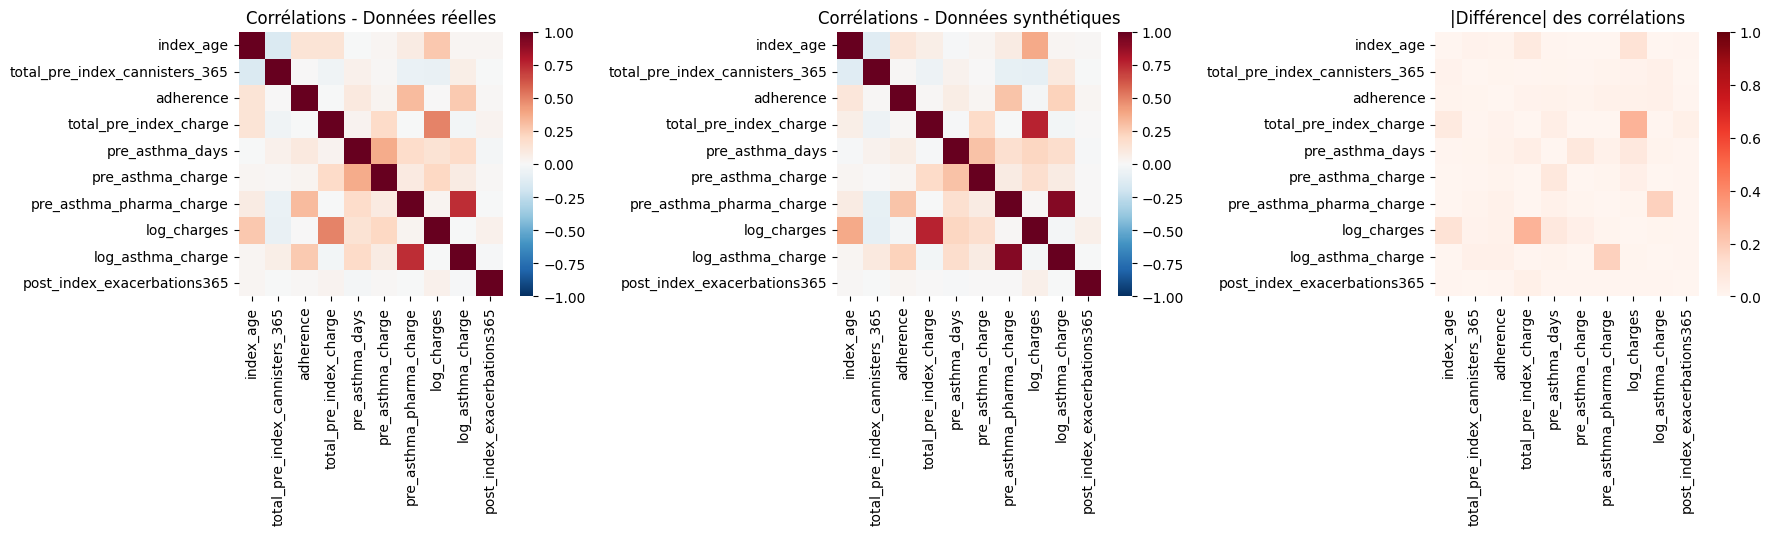

Différence moyenne absolue de corrélation : 0.0287


In [47]:
# Matrice de corrélation sur variables numériques complètes
num_cols = continuous_cols + [count_col]

corr_real = df[num_cols].corr()
corr_syn  = X_syn_df[num_cols].corr()

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

vmin, vmax = -1, 1
sns.heatmap(corr_real, ax=axes[0], cmap='RdBu_r', vmin=vmin, vmax=vmax,
            square=True, cbar=True, annot=False)
axes[0].set_title("Corrélations - Données réelles")

sns.heatmap(corr_syn, ax=axes[1], cmap='RdBu_r', vmin=vmin, vmax=vmax,
            square=True, cbar=True, annot=False)
axes[1].set_title("Corrélations - Données synthétiques")

diff = (corr_real - corr_syn).abs()
sns.heatmap(diff, ax=axes[2], cmap='Reds', vmin=0, vmax=1,
            square=True, cbar=True, annot=False)
axes[2].set_title("|Différence| des corrélations")

plt.tight_layout()
plt.savefig("correlations.png", dpi=100, bbox_inches='tight')
plt.show()

mean_corr_diff = diff.values[np.triu_indices_from(diff.values, k=1)].mean()
print(f"Différence moyenne absolue de corrélation : {mean_corr_diff:.4f}")

###Distance euclidienne au plus proche voisin (métrique de confidentialité)

Une grande distance entre les données synthétiques et les données réelles indique
un faible risque de ré-identification.

Distance euclidienne moyenne au plus proche voisin : 1.4852
(Plus la valeur est grande, meilleure est la confidentialité)


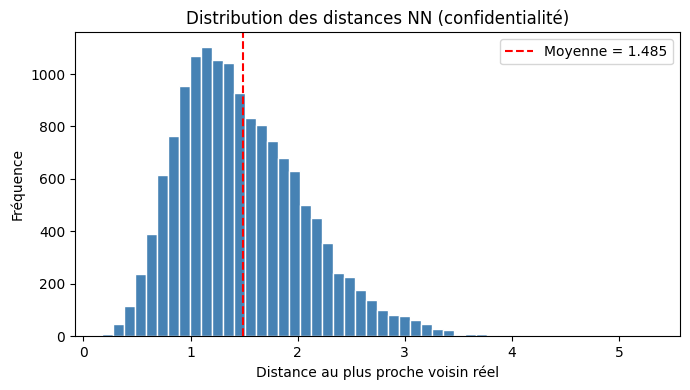

In [48]:
# Utiliser les données standardisées (sans NA) pour le calcul des distances
X_real_eval = df[feature_cols].fillna(df[feature_cols].median()).values
X_syn_eval  = X_syn_df[feature_cols].fillna(df[feature_cols].median()).values

# Standardisation commune
scaler_eval = StandardScaler().fit(X_real_eval)
X_real_std = scaler_eval.transform(X_real_eval)
X_syn_std  = scaler_eval.transform(X_syn_eval)

# Plus proche voisin : de chaque point synthétique vers les données réelles
nn = NearestNeighbors(n_neighbors=1, algorithm='auto', n_jobs=-1)
nn.fit(X_real_std)
dists, _ = nn.kneighbors(X_syn_std)
mean_nn_dist = dists.mean()

print(f"Distance euclidienne moyenne au plus proche voisin : {mean_nn_dist:.4f}")
print("(Plus la valeur est grande, meilleure est la confidentialité)")

# Distribution des distances
plt.figure(figsize=(7, 4))
plt.hist(dists.flatten(), bins=50, color='steelblue', edgecolor='white')
plt.xlabel("Distance au plus proche voisin réel")
plt.ylabel("Fréquence")
plt.title("Distribution des distances NN (confidentialité)")
plt.axvline(mean_nn_dist, color='red', linestyle='--', label=f"Moyenne = {mean_nn_dist:.3f}")
plt.legend()
plt.tight_layout()
plt.savefig("nn_distances.png", dpi=100, bbox_inches='tight')
plt.show()

### Récapitulatif des métriques

RÉCAPITULATIF DES MÉTRIQUES DE QUALITÉ
Distance de Wasserstein moyenne (continues) : 848.2083
  (0 = distributions identiques)

Différence de corrélation moyenne absolue  : 0.0287
  (0 = corrélations parfaitement conservées)

Distance NN moyenne (confidentialité)       : 1.4852
  (plus grand = meilleure confidentialité)


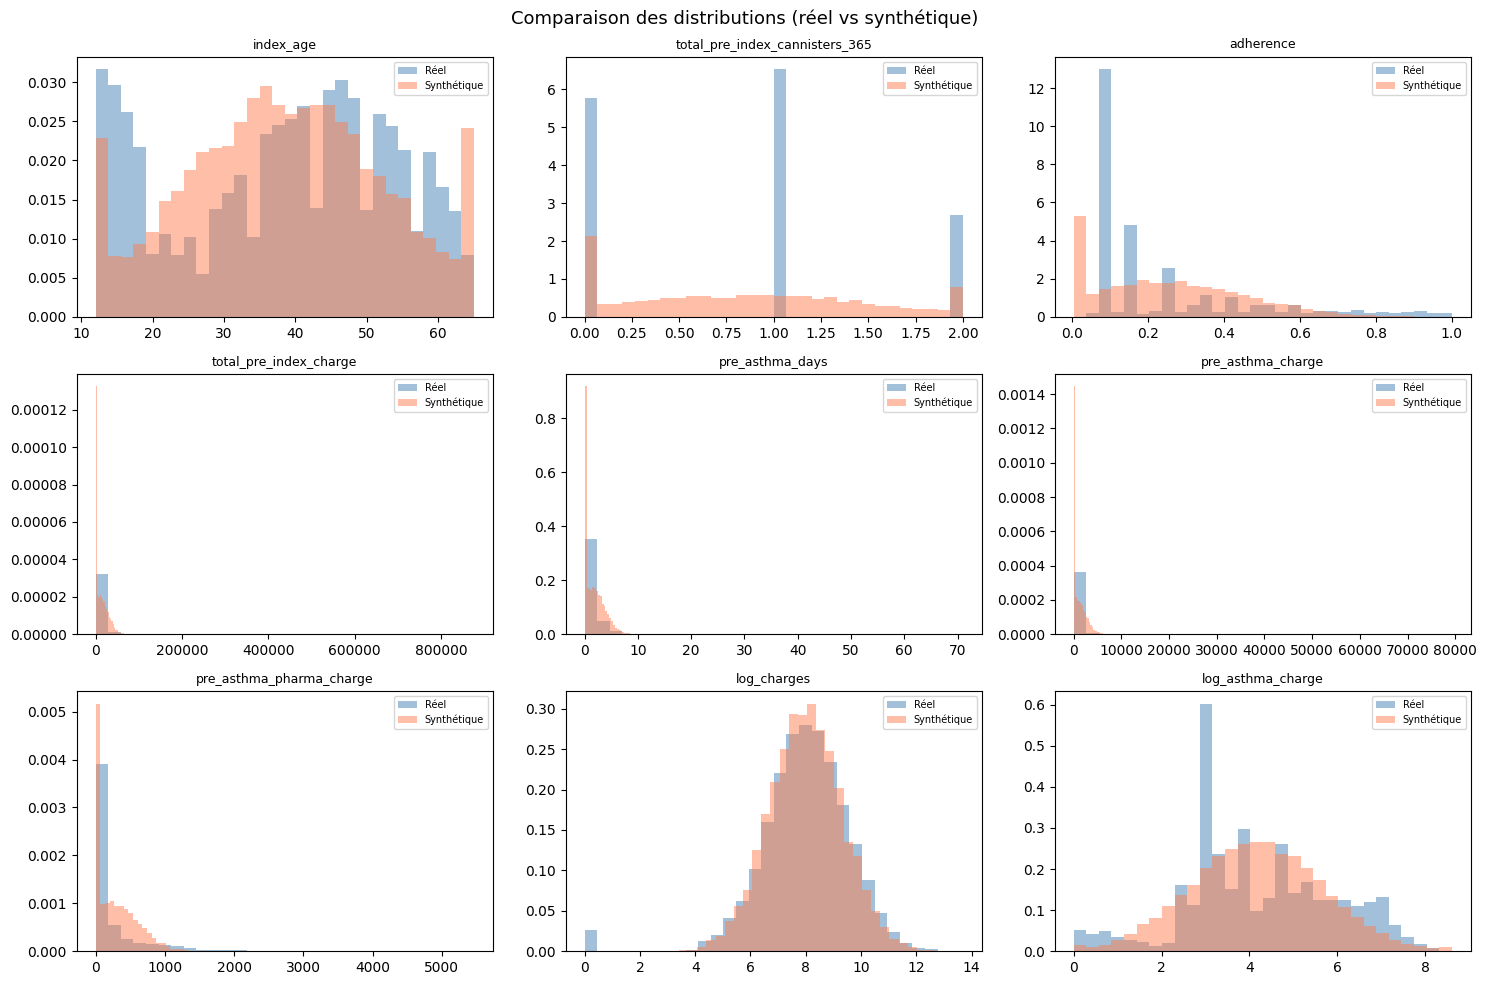

In [49]:
print("=" * 60)
print("RÉCAPITULATIF DES MÉTRIQUES DE QUALITÉ")
print("=" * 60)
print(f"Distance de Wasserstein moyenne (continues) : {mean_wd:.4f}")
print(f"  (0 = distributions identiques)")
print()
print(f"Différence de corrélation moyenne absolue  : {mean_corr_diff:.4f}")
print(f"  (0 = corrélations parfaitement conservées)")
print()
print(f"Distance NN moyenne (confidentialité)       : {mean_nn_dist:.4f}")
print(f"  (plus grand = meilleure confidentialité)")
print("=" * 60)

# Distribution comparison plots
fig, axes = plt.subplots(3, 3, figsize=(15, 10))
for ax, c in zip(axes.flatten(), continuous_cols):
    real_vals = df[c].dropna()
    syn_vals  = X_syn_df[c].dropna()
    ax.hist(real_vals, bins=30, alpha=0.5, color='steelblue', density=True, label='Réel')
    ax.hist(syn_vals,  bins=30, alpha=0.5, color='coral',    density=True, label='Synthétique')
    ax.set_title(c, fontsize=9)
    ax.legend(fontsize=7)

plt.suptitle("Comparaison des distributions (réel vs synthétique)", fontsize=13)
plt.tight_layout()
plt.savefig("distributions_comparison.png", dpi=100, bbox_inches='tight')
plt.show()

### Fichier final

In [61]:
X_syn_df = X_syn_df[df.columns]

In [62]:
list(df.columns) == list(X_syn_df.columns)

True

In [66]:
X_syn_df["index_age"] = X_syn_df["index_age"].round()

In [67]:
binary_cols = [
    "female",
    "previous_asthma_drugs",
    "pneumonia",
    "sinusitis",
    "acute_bronchitis",
    "acute_laryngitis",
    "upper_respiratory_infection",
    "gerd",
    "rhinitis"
]

for col in binary_cols:
    X_syn_df[col] = X_syn_df[col].round()

In [70]:
df["index_age"].mean()
X_syn_df["index_age"].mean()

np.float64(38.603668322506685)

In [72]:
file_name = "Groupe6_Rym_fatimazahra_dorsa_part3.csv"

X_syn_df.to_csv(file_name, index=False)

print("Dimensions :", X_syn_df.shape)

Dimensions : (14575, 21)


In [73]:
from google.colab import files

files.download(
    "Groupe6_Rym_fatimazahra_dorsa_part3.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

## Conclusion

Dans cette partie, nous avons mis en place une méthode de génération de données synthétiques basée sur l’Analyse en Composantes Principales (ACP). Les données ont d’abord été prétraitées, puis projetées dans un espace latent de dimension réduite. De nouvelles observations ont ensuite été générées dans cet espace avant d’être reconstruites dans l’espace original.

Les différentes évaluations réalisées montrent que les données synthétiques obtenues restent globalement cohérentes avec les données initiales. Les distributions de plusieurs variables sont similaires, les corrélations principales entre les variables sont globalement conservées, et les distances observées entre les données originales et synthétiques indiquent que les observations générées ne correspondent pas directement à des patients réels.

Nous observons également que la structure du jeu de données, y compris le pattern des valeurs manquantes, a été conservée dans les données synthétiques. Cela permet de produire un jeu de données réaliste et exploitable pour l’analyse tout en limitant les risques liés à la confidentialité des données médicales.

Ainsi, cette approche constitue une solution pertinente pour générer des données synthétiques qui respectent à la fois les propriétés statistiques des données initiales et les exigences de protection des données personnelles.